In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
np.random.seed(42)

In [3]:
area = np.array([1000,1200,1500,1800,2100,2400,2700,3000,3300,3600])

price = 150 * area + 50000 + np.random.randint(-15000, 15000, size=len(area))

In [4]:
df = pd.DataFrame({'Area': area, 'Price': price})
df.head()

,Area,Price
0,1000,208654
1,1200,230795
2,1500,260860
3,1800,310390
4,2100,379802


In [5]:
X = df[['Area']]
y = df['Price']

In [6]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[149.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.189e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
learned_m = model.coef_[0]
learned_b = model.intercept_

In [16]:
print(f"Learned Slope (m): {learned_m:.2f}")
print(f"Learned Intercept (b): {learned_b:.2f}")
print(f"Model Equation: Price = {learned_m:.2f} * Area + {learned_b:.2f}")

Learned Slope (m): 149.10
Learned Intercept (b): 51894.55
Model Equation: Price = 149.10 * Area + 51894.55


In [18]:
new_areas = pd.DataFrame({'Area': [1600,2800]})
predicted_prices = model.predict(new_areas)
predicted_prices

array([290461.73534338, 469387.12562814])

In [19]:
for input_area, pred_price in zip(new_areas['Area'], predicted_prices):
    print(f"Predicted price for a {input_area} sq ft house: ${pred_price:,.2f}")

Predicted price for a 1600 sq ft house: $290,461.74
Predicted price for a 2800 sq ft house: $469,387.13


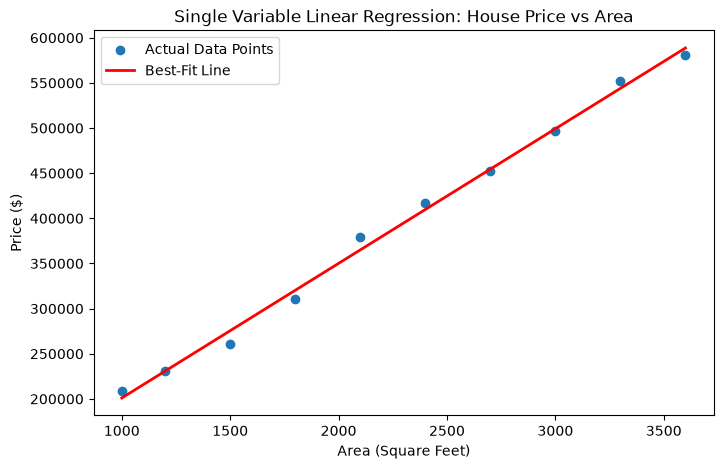

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Area'], df['Price'], label='Actual Data Points')
plt.plot(df['Area'], model.predict(X), color='red', linewidth=2, label='Best-Fit Line')
plt.xlabel('Area (Square Ft)')
plt.ylabel('Price ($)')
plt.title('Single Variable Linear Regression: House Price vs Area')
plt.legend()
plt.show()